In [191]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

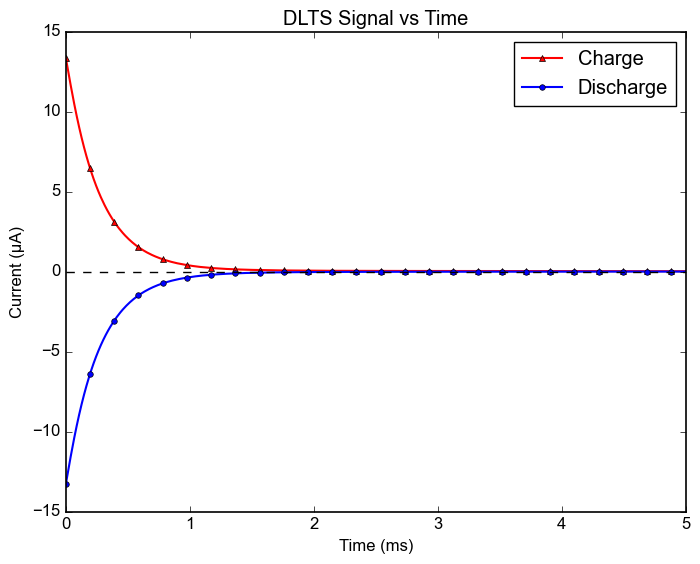

In [192]:
R2 = 1e5  # Resistance in ohms
R1 = 1e6  # Resistance in ohms

data2 = np.loadtxt("./Data_20262804/20262804007.snp")

t = data2[:, 0]
V_charge = data2[:, 1]
V_discharge = data2[:, 2]
I_charge = V_charge / R2
I_discharge = V_discharge / R2

plt.plot(t*1e3, I_charge*1e6, label='Charge', color='red', ls='-', lw = 1.5, marker='^', markersize=4, markevery=20)
plt.plot(t*1e3, I_discharge*1e6, label='Discharge', color='blue', ls='-', lw = 1.5, marker='o', markersize=4, markevery=20)
plt.axhline(y=0.0, color='black', ls='--', lw=1)

plt.xlabel('Time (ms)')
plt.ylabel('Current (µA)')
plt.title('DLTS Signal vs Time')
plt.xlim(0.00, 5)
# plt.ylim(-0.01, 1.5)
plt.legend(frameon=True, numpoints=1)
plt.show()

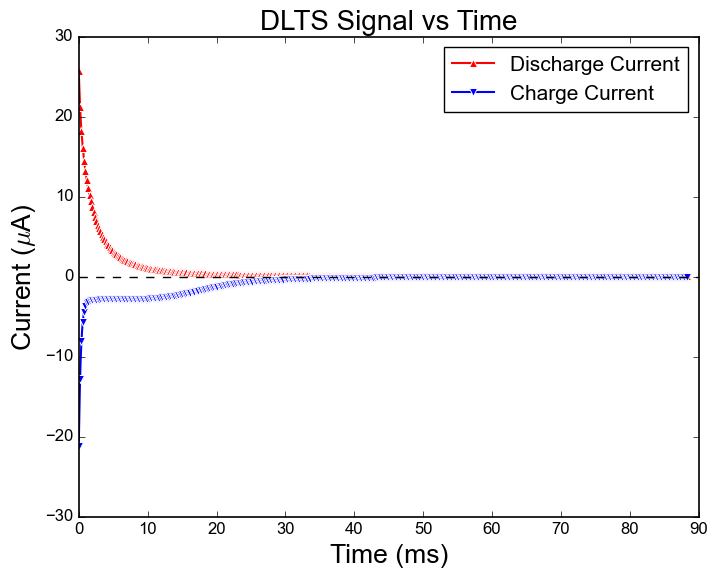

In [193]:
data2 = np.loadtxt("./Data_20262904/20262904005.snp")

t = data2[:, 0]
V_discharge = data2[:, 2]
V_charge = data2[:, 1]
I_discharge = V_discharge/R2
I_charge = V_charge/R2

# plt.figure(figsize=(8, 8))
plt.plot(t*1e3, I_discharge*1e6, label='Discharge Current', color='red', ls='-', lw = 1.5, marker='^', markevery=20,markeredgecolor="white", markeredgewidth=0.7, markersize=6)
plt.plot(t*1e3, I_charge*1e6, label='Charge Current', color='blue', ls='-', lw = 1.5, marker='v', markevery=20,markeredgecolor="white", markeredgewidth=0.7, markersize=6)
plt.axhline(y=0.0, color='black', ls='--', lw=1)
plt.xlabel('Time (ms)', fontsize=19)
plt.ylabel(r'Current ($\mu$A)', fontsize=19)
plt.title('DLTS Signal vs Time', fontsize=20)
plt.xlim(0, 90)
# plt.ylim(-2, 2)
plt.legend(frameon=True, numpoints=1, fontsize=15)
# plt.savefig('DLTS_current.eps', format='eps', bbox_inches='tight')
plt.show()

a = 1.84e-05 ± 1.32e-08
b = 0.000315 ± 3.35e-07
c = 2.85e-06 ± 1.29e-09
R^2 = 1.000
-----------------------------
C (fitted) = (0.331 ± 0.000) nF
R_L (fitted) = (7.105 ± 0.006) MΩ
Leakage current I_L = 3518.740 nA


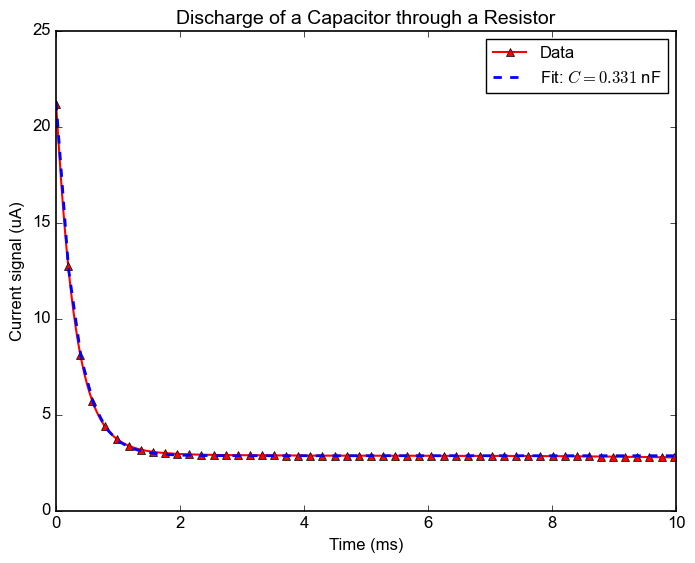

In [194]:
I_charge = -V_charge/R2

fit_current = I_charge

def func(x, a, b, c):
    return a * np.exp(-x / b) + c


mask = (t >= 0.0000) & (t <= 0.01)
# Initial guesses: a ~ peak current in window, b ~ C_actual*(R1+R2) (time constant)
if np.any(mask):
    a0 = np.max(fit_current[mask]) - np.min(fit_current[mask])
C_actual = 0.2e-9  # 10 nF
b0 = C_actual * (R1 + R2)
c0 = np.min(fit_current[mask])
p0 = [a0, b0, c0]

popt, pcov = curve_fit(func, t[mask], fit_current[mask], p0=p0, maxfev=10000)
sigma_fit = func(t[mask], *popt)
a, b, c = popt

# Coefficient of determination
ss_res = np.sum((fit_current[mask] - sigma_fit) ** 2)
ss_tot = np.sum((fit_current[mask] - np.mean(fit_current[mask])) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err, c_err = perr

R_L = a/c*(R1 + R2)
R_L_err = R_L * np.sqrt((a_err/a)**2 + (c_err/c)**2)
C = b / (1/(R1 + R2) + 1/R_L)**(-1)
C_err = b_err / (1/(R1 + R2) + 1/R_L)**(-1)

print(f"a = {a:.3g} ± {a_err:.3g}")
print(f"b = {b:.3g} ± {b_err:.3g}")
print(f"c = {c:.3g} ± {c_err:.3g}")
print(f"R^2 = {r2:.3f}")
print("-----------------------------")
print(f"C (fitted) = ({C*1e9:.3f} ± {C_err*1e9:.3f}) nF")
print(f"R_L (fitted) = ({R_L/1e6:.3f} ± {R_L_err/1e6:.3f}) MΩ")

V_T = 5
I_L = (30 - V_T) / R_L
print(f"Leakage current I_L = {I_L*1e9:.3f} nA")


x = np.linspace(0.00, 0.02, 100)
plt.plot(t*1e3, fit_current*1e6, '^', label='Data', color='red', markersize=6, ls='-', lw = 1.5, markevery=20)
plt.plot(x*1e3, func(x, *popt)*1e6, lw=2, label=rf'Fit: $C={C*1e9:.3f}$ nF', color='blue', linestyle='--')
plt.xlabel(r"Time (ms)")
plt.ylabel(r"Current signal (uA)")
plt.xlim(0.00, 10)
# plt.ylim(-0.01, 1.5)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=12)
plt.title("Discharge of a Capacitor through a Resistor", fontsize=14)
# plt.savefig("conductance_PS9.eps", format='eps', bbox_inches='tight')
plt.show()